<a href="https://colab.research.google.com/github/shivanshi-09/IML_Midterm/blob/main/LogisticRegressionDiabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

dataset = pd.read_csv("https://raw.githubusercontent.com/shivanshi-09/IML_Midterm/main/nhanes_diabetes_clean.csv")

In [53]:
drop_cols = ["SEQN", "LBXGH", "diabetes_label", "diabetes_binary"]
X = dataset.drop(columns = drop_cols)
y = dataset["diabetes_label"]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [54]:
tier1_cols =[
    "RIDAGEYR", "RIAGENDR", "RIDRETH3", # demographics
    "BMXBMI", "BMXWAIST", # anthropometric
    "BPXSY_mean", "BPXDI_mean" # blood pressure
    ]
tier2_cols = tier1_cols +[
    "LBXTC", "LBXTR", # lipids
    "LBXSCR", # creatinine
    "LBXSATSI", "LBXSASSI", # liver enzymes (ALT, AST)
    "LBXSUA" # uric acid
]
tier3_cols = tier2_cols + [
    "LBXSTP", "LBXSAL", "LBXSCA", # total protein, albumin, calcium
    "LBXSPH", "LBXSNASI", "LBXSKSI", # phosphorus, sodium, potassium
    "LBXSGB", "LBXSBU", "LBXSC3SI"# globulin, BUN, bicarbonate
]
tiers = {
    "Tier 1 (Demographic + Vitals)": tier1_cols,
    "Tier 2 (Liver Measurements)": tier2_cols,
    "Tier 3 (Full Panel)": tier3_cols
}

In [62]:
def one_hot (y, n_classes):
  out = np.zeros((len(y), n_classes))
  out[np.arange(len(y)), y.astype(int)] = 1
  return out

def softmax(z):
  z = z- np.max(z, axis = 1, keepdims = True)
  exp = np.exp(z)
  return exp / np.sum(exp, axis = 1, keepdims = True)

def forward(X, W, b):
  z = X @ W + b
  return softmax(z)

def compute_loss(Y, Y_hat):
  n = Y.shape[0]
  return -np.sum(Y* np.log(Y_hat + 1e-9))/n

def compute_gradients( X, Y, Y_hat):
  n = X.shape[0]
  dz = Y_hat - Y
  dW = (X.T @ dz)/n
  db = np.mean(dz, axis = 0)
  return dW, db

def train (X_train, Y_train, X_val, Y_val, W, b, epochs = 500, learning_rate = 0.1):
  train_losses, val_losses = [], []
  for epoch in range(epochs):
    Y_hat_train = forward(X_train, W, b)
    train_loss = compute_loss(Y_train, Y_hat_train)
    train_losses.append(train_loss)
    Y_hat_val = forward(X_val, W, b)
    test_loss = compute_loss(Y_val, Y_hat_val)
    val_losses.append(test_loss)
    dW, db = compute_gradients(X_train, Y_train, Y_hat_train)

    W -=learning_rate *dW
    b -=learning_rate *db
    if epoch % 50 == 0:
      print (f"Epoch: {epoch}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")
  return W, b, train_losses, val_losses

In [56]:
def predict(X, W, b):
  probs = forward(X, W,b)
  return np.argmax(probs, axis  = 1), probs

In [57]:
def confusion_matrix_counts (y_true, y_pred):
  TP = np.sum((y_true == 1) & (y_pred ==1))
  FP = np.sum((y_true == 0) & (y_pred ==1))
  TN = np.sum((y_true == 0) & (y_pred ==0))
  FN = np.sum((y_true == 1) & (y_pred ==0))
  return TP, FP, TN, FN

def f1_classwise(y_true, y_pred, n_classes):
  results ={}
  for c in range(n_classes):
    y_true_bin = (y_true == c).astype(int)
    y_pred_bin = (y_pred == c).astype(int)
    TP, FP, TN, FN = confusion_matrix_counts(y_true_bin, y_pred_bin)
    precision = TP / (TP + FP+ 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall)
    results [c] = {"f1": f1, "precision": precision, "recall": recall}
  return results


In [67]:
def auroc(y_true, y_prob):
  thresholds = np.linspace(0,1, 1000)
  tprs, fprs = [], []
  for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)
    TP, FP, TN, FN = confusion_matrix_counts(y_true, y_pred)
    tprs.append(TP/(TP+FN +1e-9))
    fprs.append(FP/(FP+TN +1e-9))
  fprs, tprs = zip(*sorted(zip(fprs, tprs)))
  fprs, tprs = np.array(fprs), np.array(tprs)
  auroc = np.trapezoid(tprs, fprs)
  return auroc, fprs, tprs

In [69]:
def auprc(y_true, y_prob):
    thresholds = np.linspace(0, 1, 1000)
    precisions, recalls = [], []
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        TP, FP, TN, FN = confusion_matrix_counts(y_true, y_pred)
        precisions.append(TP / (TP + FP + 1e-9))
        recalls.append(TP / (TP + FN + 1e-9))

    recalls = np.array(recalls)
    precisions = np.array(precisions)

    sorted_idx = np.argsort(recalls)
    recalls = recalls[sorted_idx]
    precisions = precisions[sorted_idx]

    auprc_val = np.trapezoid(precisions, recalls)
    return auprc_val, recalls, precisions


 ------- Tier 1 (Demographic + Vitals)-----------
Epoch: 0, Train Loss: 1.9859, Test Loss: 2.0576
Epoch: 50, Train Loss: 0.8241, Test Loss: 0.7990
Epoch: 100, Train Loss: 0.7754, Test Loss: 0.7524
Epoch: 150, Train Loss: 0.7660, Test Loss: 0.7440
Epoch: 200, Train Loss: 0.7630, Test Loss: 0.7413
Epoch: 250, Train Loss: 0.7617, Test Loss: 0.7400
Epoch: 300, Train Loss: 0.7610, Test Loss: 0.7394
Epoch: 350, Train Loss: 0.7606, Test Loss: 0.7391
Epoch: 400, Train Loss: 0.7603, Test Loss: 0.7388
Epoch: 450, Train Loss: 0.7602, Test Loss: 0.7387


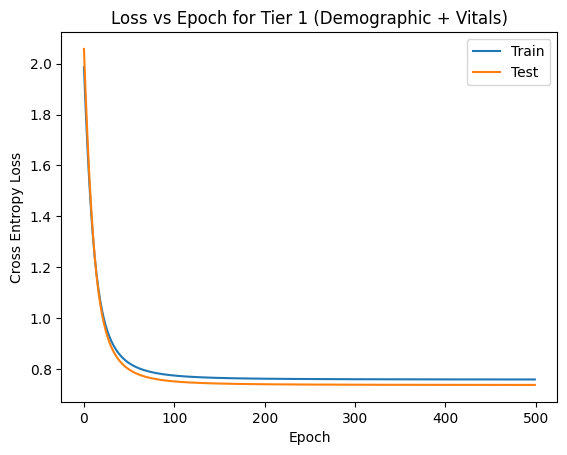

Class 0 | F1: 0.7884  AUROC: 0.8108  AUPRC: 0.8780
Class 1 | F1: 0.4058  AUROC: 0.7238  AUPRC: 0.4223
Class 2 | F1: 0.1566  AUROC: 0.7801  AUPRC: 0.2918

 ------- Tier 2 (Liver Measurements)-----------
Epoch: 0, Train Loss: 1.8895, Test Loss: 1.9710
Epoch: 50, Train Loss: 0.8136, Test Loss: 0.7914
Epoch: 100, Train Loss: 0.7670, Test Loss: 0.7477
Epoch: 150, Train Loss: 0.7578, Test Loss: 0.7394
Epoch: 200, Train Loss: 0.7544, Test Loss: 0.7363
Epoch: 250, Train Loss: 0.7528, Test Loss: 0.7347
Epoch: 300, Train Loss: 0.7518, Test Loss: 0.7339
Epoch: 350, Train Loss: 0.7512, Test Loss: 0.7334
Epoch: 400, Train Loss: 0.7508, Test Loss: 0.7331
Epoch: 450, Train Loss: 0.7506, Test Loss: 0.7329


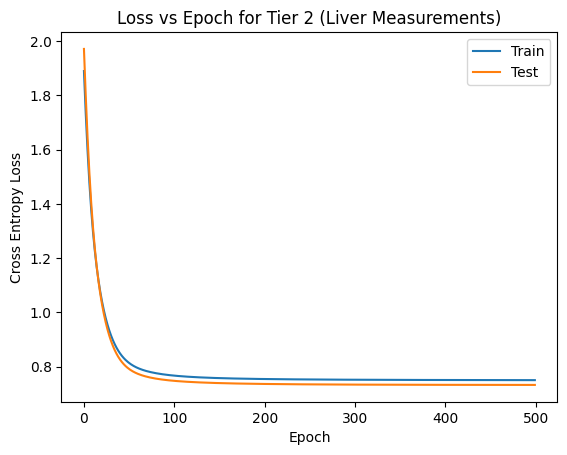

Class 0 | F1: 0.7891  AUROC: 0.8144  AUPRC: 0.8795
Class 1 | F1: 0.4092  AUROC: 0.7261  AUPRC: 0.4189
Class 2 | F1: 0.2632  AUROC: 0.7908  AUPRC: 0.3100

 ------- Tier 3 (Full Panel)-----------
Epoch: 0, Train Loss: 1.6919, Test Loss: 1.7263
Epoch: 50, Train Loss: 0.8069, Test Loss: 0.7855
Epoch: 100, Train Loss: 0.7563, Test Loss: 0.7354
Epoch: 150, Train Loss: 0.7442, Test Loss: 0.7239
Epoch: 200, Train Loss: 0.7394, Test Loss: 0.7193
Epoch: 250, Train Loss: 0.7371, Test Loss: 0.7171
Epoch: 300, Train Loss: 0.7358, Test Loss: 0.7158
Epoch: 350, Train Loss: 0.7350, Test Loss: 0.7151
Epoch: 400, Train Loss: 0.7344, Test Loss: 0.7146
Epoch: 450, Train Loss: 0.7340, Test Loss: 0.7144


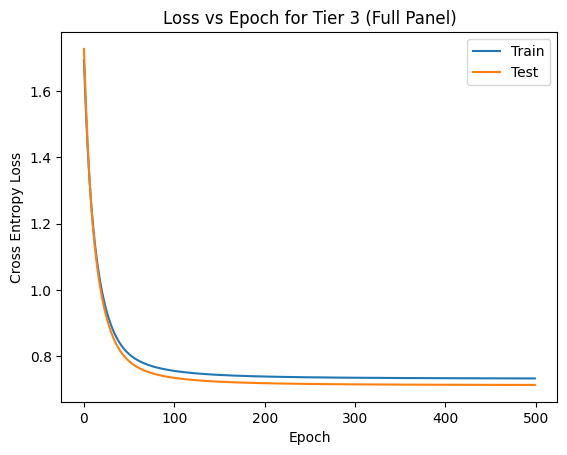

Class 0 | F1: 0.7968  AUROC: 0.8236  AUPRC: 0.8839
Class 1 | F1: 0.4191  AUROC: 0.7388  AUPRC: 0.4483
Class 2 | F1: 0.3054  AUROC: 0.8196  AUPRC: 0.3838


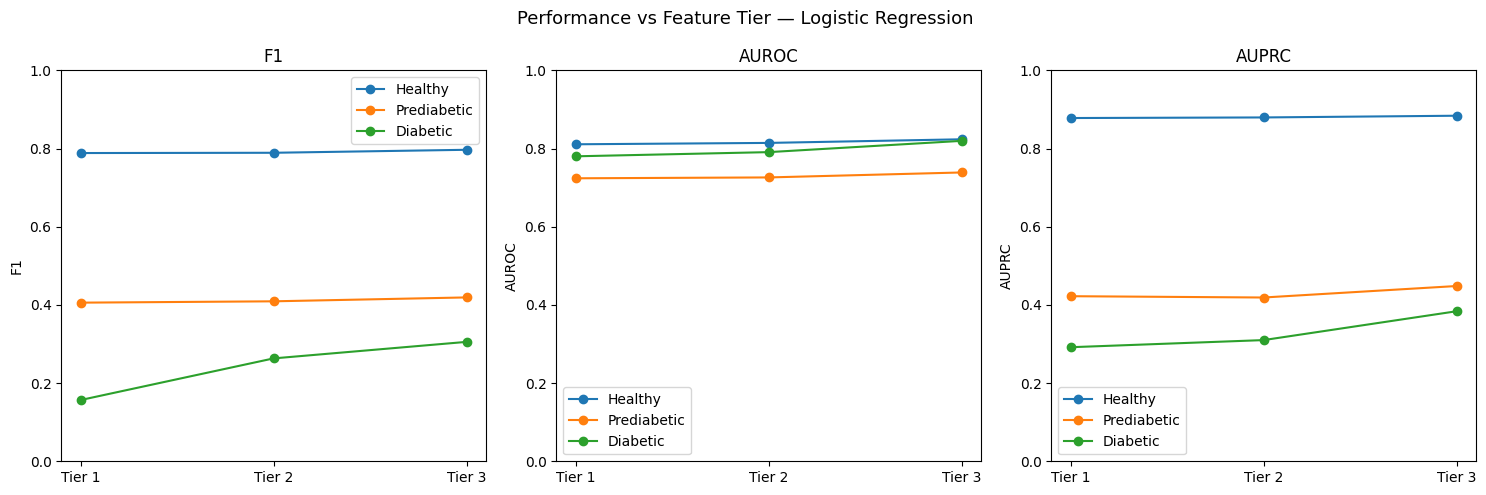

In [70]:
n_classes = 3
tier_results = {}

for tier_name, cols in tiers.items():
  print(f"\n ------- {tier_name}-----------")
  scaler = StandardScaler()
  X_train_tier = scaler.fit_transform(x_train[cols])
  X_test_tier = scaler.transform(x_test[cols])

  Y_train_tier = one_hot(y_train.values, n_classes)
  Y_test_tier = one_hot(y_test.values, n_classes)
  n_feat = X_train_tier.shape[1]
  np.random.seed(42)
  W_t = np.random.randn(n_feat, n_classes) *np.sqrt(2.0/n_feat)
  b_t = np.zeros(n_classes)
  W_t, b_t, train_losses, test_losses = train(
      X_train_tier, Y_train_tier, X_test_tier, Y_test_tier, W_t, b_t
  )
  plt.plot(train_losses, label = "Train")
  plt.plot(test_losses, label = "Test")
  plt.legend()
  plt.xlabel("Epoch")
  plt.ylabel("Cross Entropy Loss")
  plt.title(f"Loss vs Epoch for {tier_name}")
  plt.show()

  y_pred, y_probs = predict (X_test_tier, W_t, b_t)
  y_true = y_test.values
  f1_scores  = f1_classwise(y_true, y_pred, n_classes)

  tier_results[tier_name] = {"f1":{}, "auroc":{}, "auprc":{}}
  for c in range(n_classes):
    y_true_bin = (y_true == c).astype(int)
    y_prob_c = y_probs[:,c]
    auroc_val, fprs, tprs = auroc(y_true_bin, y_prob_c)
    auprc_val, precision, recall = auprc(y_true_bin, y_prob_c)
    f1_val = f1_scores[c]["f1"]
    tier_results[tier_name]["f1"][c]  = f1_val
    tier_results[tier_name]["auroc"][c] = auroc_val
    tier_results[tier_name]["auprc"][c]= auprc_val
    print(f"Class {c} | F1: {f1_val:.4f}  AUROC: {auroc_val:.4f}  AUPRC: {auprc_val:.4f}")
class_names = ["Healthy", "Prediabetic", "Diabetic"]
tier_names = list(tier_results.keys())
fig, axes = plt.subplots(1, 3, figsize = (15, 5))
for ax, metric, label in zip(axes, ["f1", "auroc", "auprc"], ["F1", "AUROC", "AUPRC"]):
  for c, cname in enumerate(class_names):
    scores = [tier_results[t][metric][c] for t in tier_names]
    ax.plot(["Tier 1", "Tier 2", "Tier 3"], scores, marker = "o", label = cname)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.legend()
    ax.set_ylim(0, 1)
plt.suptitle("Performance vs Feature Tier — Logistic Regression", fontsize=13)
plt.tight_layout()
plt.show()
